In [1]:
# Cell: install
# Run this cell first. It installs PyTorch, Transformers, sentence-transformers, sklearn, and openpyxl for Excel.
# On Colab this will download model weights when first used.
!pip install -qU torch torchvision torchaudio
!pip install -qU transformers sentence-transformers
!pip install -qU scikit-learn pandas openpyxl tqdm matplotlib seaborn

In [2]:
# Cell: imports and config
import os, random, json, re, math
from pathlib import Path
from time import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModel, AutoTokenizer

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
from google.colab import files
uploaded = files.upload()
#BASE = Path("/content/phase2_output")
#BASE.mkdir(exist_ok=True)
#DATA_XLSX = Path("/content/Dataset.xlsx")  # upload to Colab root or edit path to mounted Drive


Saving ann_ai.txt to ann_ai (1).txt
Saving ann_hum.txt to ann_hum (1).txt
Saving Dataset.xlsx to Dataset (1).xlsx
Saving DEI_AI.txt to DEI_AI (1).txt
Saving dei_hum.txt to dei_hum (1).txt
Saving eg_ai.txt to eg_ai (1).txt
Saving eg_hum.txt to eg_hum (1).txt
Saving ISL_ai.txt to ISL_ai (1).txt
Saving isl_hum.txt to isl_hum (1).txt
Saving sust_ai.txt to sust_ai (1).txt
Saving sust_hum.txt to sust_hum (1).txt


In [3]:
# Cell: imports and config
import os, random, json, re, math
from pathlib import Path
from time import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModel, AutoTokenizer

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
BASE = Path("/content/phase2_output")
BASE.mkdir(exist_ok=True)
DATA_XLSX = Path("/content/Dataset.xlsx")  # upload to Colab root or edit path to mounted Drive


In [4]:
# Cell: load dataset (edit path if using Drive)
assert DATA_XLSX.exists(), f"Upload your Dataset.xlsx to {DATA_XLSX} or mount Drive and update path."

df = pd.read_excel(str(DATA_XLSX))
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()


Columns: ['sr.no', 'text', 'source', 'label_name', 'label_id']
Shape: (11580, 5)


,sr.no,text,source,label_name,label_id
0,0,"Produced by Chris Young Ritzen, Tamara Weitzma...",openwebtext,human-written,1
1,1,"Lawrence Eugene Doby (December 13, 1923 – June...",openwebtext,human-written,1
2,2,Shock and Awe\n\nGabe Newell is about to make ...,openwebtext,human-written,1
3,3,The Best Answers to Tough Interview Questions\...,openwebtext,human-written,1
4,4,Contents:\n\n1.) Preamble\n\n2.) Understand Yo...,openwebtext,human-written,1


In [5]:
# Cell: preprocessing utilities

def normalize_text(s):
    if pd.isna(s): return ""
    s = str(s)
    s = s.replace("\r", " ").replace("\n", " ").strip()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("—","-").replace("–","-").replace("“",'"').replace("”",'"').replace("’","'")
    s = re.sub(r"([!?.]){2,}", r"\1", s)
    return s

# prompt leakage removal heuristics (customize as needed)
PROMPT_PATTERNS = [
    r"Generated by.*", r"This was generated by.*", r"assistant:", r"human:", r"system:",
    r"Prompt:.*", r"Input:.*", r"Output:.*"
]
PROMPT_REGEX = re.compile("|".join(PROMPT_PATTERNS), flags=re.IGNORECASE)

def remove_prompt_leakage(s):
    # remove known prompt-like substrings
    s = PROMPT_REGEX.sub("", s)
    # drop trailing tokens like 'Generated by ChatGPT'
    s = re.sub(r"\b(generated by|created by|written by)\b.*", "", s, flags=re.IGNORECASE)
    return s.strip()

def length_stats(texts):
    lens = [len(t.split()) for t in texts]
    return {"count": len(lens), "mean_words": np.mean(lens), "median_words": np.median(lens), "std": np.std(lens)}

# lexical burstiness: variance-to-mean of word frequencies (simple proxy)
def burstiness(texts):
    from collections import Counter
    cnt = Counter()
    for t in texts:
        cnt.update(re.findall(r"\w+", t.lower()))
    freqs = np.array(list(cnt.values()))
    return freqs.var() / (freqs.mean() + 1e-9)

# entropy estimate per-sample (token-level)
def avg_entropy(texts):
    import math
    entropies = []
    for t in texts:
        toks = re.findall(r"\w+", t.lower())
        if not toks:
            entropies.append(0.0)
            continue
        from collections import Counter
        c = Counter(toks)
        probs = np.array(list(c.values())) / len(toks)
        ent = -np.sum(probs * np.log2(probs + 1e-12))
        entropies.append(ent)
    return float(np.mean(entropies))


In [6]:
# === HRS DOCUMENT-LEVEL LOADER (NO SEGMENTATION) ===
# Human re-authoring counterfactuals. Not training data.

def clean_layout_noise(text):
    lines = text.splitlines()
    cleaned = []
    for ln in lines:
        ln_strip = ln.strip()

        # remove page numbers / headers
        if re.fullmatch(r"\d+", ln_strip):
            continue
        if re.search(r"(page\s+\d+)", ln_strip.lower()):
            continue

        cleaned.append(ln)
    return normalize_text("\n".join(cleaned))


HRS_FILES = [
    ("eg_ai.txt",   "eg_hum.txt",   "education"),
    ("DEI_AI.txt",  "dei_hum.txt",  "policy"),
    ("sust_ai.txt", "sust_hum.txt", "sustainability"),
    ("ann_ai.txt",  "ann_hum.txt",  "detection"),
    ("ISL_ai.txt",  "isl_hum.txt",  "sign")
]


def load_clean_doc(path):
    with open(path, "r", encoding="utf-8") as f:
        return clean_layout_noise(f.read())

hrs_docs = []
for ai_f, hum_f, domain in HRS_FILES:
    hrs_docs.append({
        "id": ai_f.replace(".txt",""),
        "domain": domain,
        "ai_text": load_clean_doc(ai_f),
        "hum_text": load_clean_doc(hum_f)
    })

print("Loaded HRS documents:", [d["id"] for d in hrs_docs])


Loaded HRS documents: ['eg_ai', 'DEI_AI', 'sust_ai', 'ann_ai', 'ISL_ai']


In [7]:
# Cell: artifact-controlled dataset construction
# You must specify which columns are text and label in your Excel file.
# Adjust these names if your sheet uses different column headers.

TEXT_COL = "text"      # change if needed
# label could be a numeric id (0 human, 1 ai) or a string. Try common candidates automatically:
LABEL_COL_CANDIDATES = ["label_id", "label", "label_name", "source", "class"]

label_col = None
for c in LABEL_COL_CANDIDATES:
    if c in df.columns:
        label_col = c
        break

# If still None, try to guess text/label automatically:
if TEXT_COL not in df.columns:
    # pick longest object column as text
    obj_cols = [c for c in df.columns if df[c].dtype==object]
    TEXT_COL = max(obj_cols, key=lambda c: df[c].dropna().astype(str).map(len).mean())

if label_col is None:
    # try to infer from a column which has 2 unique values
    for c in df.columns:
        if df[c].nunique() == 2:
            label_col = c
            break

assert TEXT_COL in df.columns, "Adjust TEXT_COL to the actual text column in your Dataset.xlsx"
assert label_col is not None, "Label column not found — adjust LABEL_COL_CANDIDATES or provide a label column."

print("Using text column:", TEXT_COL, "using label column:", label_col)

# Clean and remove prompt leakage
df['text_clean'] = df[TEXT_COL].astype(str).apply(normalize_text).apply(remove_prompt_leakage)

# Normalize labels to 0/1
def normalize_label(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, np.integer)) and v in (0,1): return int(v)
    s = str(v).lower()
    if any(tok in s for tok in ["ai","gpt","model","generated","bot"]): return 1
    if any(tok in s for tok in ["human","real","writer","annotator"]): return 0
    # fallback: return nan
    return np.nan

df['label_norm'] = df[label_col].apply(normalize_label)
df = df.dropna(subset=['text_clean','label_norm']).reset_index(drop=True)
df['label_norm'] = df['label_norm'].astype(int)

# Basic filtering: length parity (remove extreme outliers)
df['num_words'] = df['text_clean'].str.split().apply(len)
low, high = df['num_words'].quantile(0.01), df['num_words'].quantile(0.99)
df = df[(df['num_words'] >= low) & (df['num_words'] <= high)].reset_index(drop=True)

# Domain balancing (optional): create domain labels if available (you can skip)
# For now, keep as-is and report per-domain sizes if 'source' exists
if 'source' in df.columns:
    domain_counts = df.groupby('source')['label_norm'].value_counts().unstack(fill_value=0)
    print("Per-source counts:\n", domain_counts)

# Save artifact-controlled cleaned dataset
CLEANED_CSV = BASE / "cleaned_dataset.csv"
df[['text_clean','label_norm','num_words']].rename(columns={'text_clean':'text','label_norm':'label'}).to_csv(CLEANED_CSV, index=False)
print("Saved cleaned dataset to", CLEANED_CSV)
print("Dataset size:", df.shape)
print("Length stats (overall):", length_stats(df['text'].tolist()))
print("Burstiness:", burstiness(df['text'].tolist()))
print("Avg entropy:", avg_entropy(df['text'].tolist()))


Using text column: text using label column: label_id
Per-source counts:
 label_norm              0     1
source                         
answers                 0   645
blog                    0   195
chatgpt              1111     0
davinci               427     0
flan_t5               391     0
gpt-3                 294     0
gpt-3.5               356     0
gpt-4                 726     0
gpt2                  323     0
news articles           0   404
openwebtext             0  2250
opinion statements      0  1542
opt-iml               400     0
paraphrase           1691     0
scientific research     0   202
webtext                 0   394
Saved cleaned dataset to /content/phase2_output/cleaned_dataset.csv
Dataset size: (11351, 8)
Length stats (overall): {'count': 11351, 'mean_words': np.float64(689.6868998326139), 'median_words': np.float64(549.0), 'std': np.float64(404.7642687135379)}
Burstiness: 56004.72647581434
Avg entropy: 7.443494756695839


In [8]:
# === DATASET INTEGRITY GUARANTEE ===

def dataset_integrity(df):
    assert 'text_clean' in df.columns
    assert 'label_norm' in df.columns
    assert set(df['label_norm'].unique()) == {0,1}

    print("Dataset OK")
    print("Label balance:", df['label_norm'].value_counts(normalize=True))

dataset_integrity(df)


Dataset OK
Label balance: label_norm
0    0.503832
1    0.496168
Name: proportion, dtype: float64


In [9]:
# === COMPRESSION BASELINE (NON-LEARNED) ===
# Training-free detector surrogate

import zlib

def compression_ratio(text):
    raw = text.encode("utf-8")
    return len(zlib.compress(raw, 9)) / len(raw)


In [10]:
# Cell: TV distance and distribution diagnostics (unigram-based)
from collections import Counter
def unigram_dist(texts, top_k=2000):
    cnt = Counter()
    for t in texts:
        toks = re.findall(r"\w+", t.lower())
        cnt.update(toks)
    total = sum(cnt.values())
    if total == 0:
        return {}
    d = {k: v/total for k,v in cnt.items()}
    # keep top_k
    items = sorted(d.items(), key=lambda x: -x[1])[:top_k]
    s = sum(x[1] for x in items)
    return {k:v/s for k,v in items}

def tv_distance(d1, d2):
    keys = set(d1.keys()) | set(d2.keys())
    return 0.5 * sum(abs(d1.get(k,0) - d2.get(k,0)) for k in keys)

human_texts = df[df['label_norm']==0]['text_clean'].tolist()
ai_texts    = df[df['label_norm']==1]['text_clean'].tolist()
d_h = unigram_dist(human_texts)
d_ai = unigram_dist(ai_texts)
tv = tv_distance(d_h, d_ai)
print(f"Unigram TV distance (top {len(d_h)}): {tv:.4f}")

# Report length distributions by label
print("Human length stats:", length_stats(human_texts))
print("AI length stats:", length_stats(ai_texts))

Unigram TV distance (top 2000): 0.0978
Human length stats: {'count': 5719, 'mean_words': np.float64(522.6394474558489), 'median_words': np.float64(470.0), 'std': np.float64(157.22043164522194)}
AI length stats: {'count': 5632, 'mean_words': np.float64(834.3948863636364), 'median_words': np.float64(707.0), 'std': np.float64(476.1335151503398)}


In [11]:
# === COMPRESSION BASELINE: SANITY CHECK ===

comp_ai = [compression_ratio(t) for t in ai_texts[:200]]
comp_hu = [compression_ratio(t) for t in human_texts[:200]]

print("Compression mean (AI):", np.mean(comp_ai))
print("Compression mean (Human):", np.mean(comp_hu))


Compression mean (AI): 0.4181101515616443
Compression mean (Human): 0.44806547257485013


In [12]:
# Cell: paraphrasing
# Two paraphrasers:
#  1) deterministic synonym + phrase reorder (fast, reproducible)
#  2) optional transformer paraphraser using T5-based model (slower, higher-quality)
#
# Enable TRANSFORMER_PARAPHRASE = True to run transformer-based paraphrasing (requires GPU & time).

TRANSFORMER_PARAPHRASE = False   # set to True only if you want transformer-based paraphrasing
PARAPHRASE_SAMPLE_SIZE = None    # if set, will limit paraphrasing to this many AI samples for speed (None = all)

# 1) deterministic paraphraser
SYNONYM_MAP = {
    "good": ["decent", "pleasant", "fine"],
    "great": ["excellent", "superb", "wonderful"],
    "bad": ["poor", "suboptimal"],
    "love": ["adore", "cherish", "really like"],
    "recommend": ["suggest", "endorse"],
    "price": ["cost", "rate"],
    "quality": ["caliber", "standard"],
    "fabric": ["material", "textile"]
}

def simple_synonym_paraphrase(text, prob=0.45):
    words = text.split()
    out = []
    for w in words:
        key = re.sub(r'[^\w]', '', w).lower()
        if key in SYNONYM_MAP and random.random() < prob:
            choice = random.choice(SYNONYM_MAP[key])
            # preserve capitalization
            if w[0].isupper():
                choice = choice.capitalize()
            # preserve trailing punctuation
            m = re.search(r'(\W+)$', w)
            if m: choice = choice + m.group(1)
            out.append(choice)
        else:
            out.append(w)
    return " ".join(out)

def phrase_shuffle(text, prob=0.25):
    # naive split on commas and ' and '
    parts = re.split(r',| and ', text)
    parts = [p.strip() for p in parts if p.strip()]
    if len(parts) <= 1 or random.random() > prob:
        return text
    random.shuffle(parts)
    return ", ".join(parts)

def paraphrase_deterministic(text, depth=1):
    # apply synonym replacement and occasional phrase shuffle `depth` times
    out = text
    for _ in range(depth):
        out = simple_synonym_paraphrase(out, prob=0.45)
        out = phrase_shuffle(out, prob=0.25)
    return out

# 2) transformer paraphraser (optional)
if TRANSFORMER_PARAPHRASE:
    # model choice: small T5-paraphraser. This will be loaded from HuggingFace and requires GPU.
    # Example model name (works in many setups): "Vamsi/T5_Paraphrase_Paws"
    # You can change the model here. Note: different models require different input prompts.
    PARAPHRASER_MODEL = "Vamsi/T5_Paraphrase_Paws"
    tok_para = AutoTokenizer.from_pretrained(PARAPHRASER_MODEL)
    model_para = AutoModelForSeq2SeqLM.from_pretrained(PARAPHRASER_MODEL).to("cuda" if torch.cuda.is_available() else "cpu")
    def paraphrase_transformer(text, num_return_sequences=1, max_length=256):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        input_text = "paraphrase: " + text + " </s>"
        encoding = tok_para.encode_plus(input_text, padding='longest', return_tensors="pt", truncation=True, max_length=256).to(device)
        outputs = model_para.generate(**encoding, max_length=256, num_beams=4, num_return_sequences=num_return_sequences, early_stopping=True)
        paraphrases = [tok_para.decode(o, skip_special_tokens=True, clean_up_tokenization_spaces=True) for o in outputs]
        return paraphrases[0] if paraphrases else text

# Generate paraphrases for AI samples
ai_df = df[df['label_norm']==1].reset_index(drop=True)
if PARAPHRASE_SAMPLE_SIZE is not None:
    ai_df = ai_df.sample(n=PARAPHRASE_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

ai_texts = ai_df['text_clean'].tolist()
par_depth1 = []
par_depth2 = []

if TRANSFORMER_PARAPHRASE:
    print("Running transformer paraphraser (may take long)...")
    for t in tqdm(ai_texts, desc="transformer para"):
        p1 = paraphrase_transformer(t, num_return_sequences=1)
        p2 = paraphrase_transformer(p1, num_return_sequences=1)
        par_depth1.append(p1); par_depth2.append(p2)
else:
    print("Using deterministic paraphraser (fast).")
    for t in tqdm(ai_texts, desc="deterministic para"):
        p1 = paraphrase_deterministic(t, depth=1)
        p2 = paraphrase_deterministic(p1, depth=1)
        par_depth1.append(p1); par_depth2.append(p2)

ai_df['paraphrase_depth1'] = par_depth1
ai_df['paraphrase_depth2'] = par_depth2

AI_PARAS_PATH = BASE / "ai_paraphrases_depths.csv"
ai_df.to_csv(AI_PARAS_PATH, index=False)
print("Saved AI paraphrases to", AI_PARAS_PATH)

# Build mixed evaluation sets (human + AI paraphrases)
hum_df = (
    df[df['label_norm']==0][['text_clean']]
    .rename(columns={'text_clean':'text'})
    .reset_index(drop=True)
)
hum_df['label'] = 0

par1 = pd.concat([hum_df, ai_df[['paraphrase_depth1']].rename(columns={'paraphrase_depth1':'text'}).assign(label=1)], ignore_index=True)
par2 = pd.concat([hum_df, ai_df[['paraphrase_depth2']].rename(columns={'paraphrase_depth2':'text'}).assign(label=1)], ignore_index=True)
par1.to_csv(BASE / "paraphrase_depth1.csv", index=False)
par2.to_csv(BASE / "paraphrase_depth2.csv", index=False)
print("Saved paraphrase depth CSVs:", (BASE / "paraphrase_depth1.csv"), (BASE / "paraphrase_depth2.csv"))

Using deterministic paraphraser (fast).


deterministic para: 100%|██████████| 5632/5632 [00:09<00:00, 591.43it/s] 


Saved AI paraphrases to /content/phase2_output/ai_paraphrases_depths.csv
Saved paraphrase depth CSVs: /content/phase2_output/paraphrase_depth1.csv /content/phase2_output/paraphrase_depth2.csv


In [13]:
# === PARAPHRASE SEMANTIC QUALITY CHECK ===

from sentence_transformers import SentenceTransformer, util

device_eval = "cuda" if torch.cuda.is_available() else "cpu"
_eval_sbert = SentenceTransformer("all-mpnet-base-v2", device=device_eval)

def paraphrase_similarity(orig, para, n=300):
    idx = np.random.choice(len(orig), min(n, len(orig)), replace=False)
    sims = []
    for i in idx:
        e1 = _eval_sbert.encode(orig[i], convert_to_tensor=True)
        e2 = _eval_sbert.encode(para[i], convert_to_tensor=True)
        sims.append(util.cos_sim(e1, e2).item())
    return np.mean(sims), np.std(sims)

mean1, std1 = paraphrase_similarity(ai_texts, par_depth1)
mean2, std2 = paraphrase_similarity(par_depth1, par_depth2)

print("Depth1 similarity:", mean1, "±", std1)
print("Depth2 similarity:", mean2, "±", std2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Depth1 similarity: 0.9567878254254659 ± 0.0927401969119567
Depth2 similarity: 0.9539193046092987 ± 0.09610364532806392


In [14]:
# Cell: create controlled 900-sample benchmark (2/3 balance) — adjust as needed
BENCHMARK_SIZE = 900
# choose sample per-class: half human, half ai_orig, plus paraphrases later when evaluating
n_human = BENCHMARK_SIZE // 3   # roughly 300 human
n_ai = BENCHMARK_SIZE // 3
n_parap = BENCHMARK_SIZE - n_human - n_ai

hum_sample = df[df['label_norm']==0].sample(n=n_human, random_state=SEED)[['text_clean']].rename(columns={'text_clean':'text'}).reset_index(drop=True)
ai_sample = df[df['label_norm']==1].sample(n=n_ai, random_state=SEED)[['text_clean']].rename(columns={'text_clean':'text'}).reset_index(drop=True)
# For paraphrases, sample from ai_df paraphrase lists
para_sample1 = ai_df.sample(n=n_parap, random_state=SEED)[['paraphrase_depth1']].rename(columns={'paraphrase_depth1':'text'}).reset_index(drop=True)
para_sample2 = ai_df.sample(n=n_parap, random_state=SEED)[['paraphrase_depth2']].rename(columns={'paraphrase_depth2':'text'}).reset_index(drop=True)

bench_clean = pd.concat([hum_sample.assign(label=0), ai_sample.assign(label=1)], ignore_index=True)
bench_p1 = pd.concat([hum_sample.assign(label=0), para_sample1.assign(label=1)], ignore_index=True)
bench_p2 = pd.concat([hum_sample.assign(label=0), para_sample2.assign(label=1)], ignore_index=True)

bench_clean.to_csv(BASE / "benchmark_clean.csv", index=False)
bench_p1.to_csv(BASE / "benchmark_p1.csv", index=False)
bench_p2.to_csv(BASE / "benchmark_p2.csv", index=False)
print("Saved benchmark CSVs (clean, p1, p2) to", BASE)

Saved benchmark CSVs (clean, p1, p2) to /content/phase2_output


In [15]:
# Cell: SBERT embeddings + shallow classifier
# We'll use 'all-mpnet-base-v2' as SBERT default (you can change)
SBERT_MODEL = "all-mpnet-base-v2"
print("Loading SBERT:", SBERT_MODEL)
sbert = SentenceTransformer(SBERT_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")

def fit_embedding_classifier(embeds_train, y_train, embeds_test, y_test):
    # Use Logistic Regression on embeddings with optional scaling
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(embeds_train)
    Xte = scaler.transform(embeds_test)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, y_train)
    probs = clf.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, probs)
    return clf, scaler, auc, probs

# Prepare embeddings for clean train/test (use cleaned CSV)
clean = pd.read_csv(CLEANED_CSV)
X = clean['text'].fillna('').tolist(); y = clean['label'].tolist()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Embedding training on", len(Xtr), "samples")

# Encode in batches (SentenceTransformer handles batching)
emb_tr = sbert.encode(Xtr, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
emb_te = sbert.encode(Xte, batch_size=64, show_progress_bar=True, convert_to_numpy=True)

clf_sbert, scaler_sbert, auc_sbert_clean, probs_sbert = fit_embedding_classifier(emb_tr, ytr, emb_te, yte)
print("SBERT logistic AUROC on clean test:", auc_sbert_clean)

# Evaluate on paraphrase datasets (depth1 & depth2)
par1 = pd.read_csv(BASE / "paraphrase_depth1.csv")
par2 = pd.read_csv(BASE / "paraphrase_depth2.csv")
emb_par1 = sbert.encode(par1['text'].fillna('').tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True)
emb_par2 = sbert.encode(par2['text'].fillna('').tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True)
Xpar1_scaled = scaler_sbert.transform(emb_par1)
Xpar2_scaled = scaler_sbert.transform(emb_par2)
probs_par1 = clf_sbert.predict_proba(Xpar1_scaled)[:,1]
probs_par2 = clf_sbert.predict_proba(Xpar2_scaled)[:,1]



Loading SBERT: all-mpnet-base-v2
Embedding training on 9080 samples


Batches:   0%|          | 0/142 [00:00<?, ?it/s]

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

SBERT logistic AUROC on clean test: 0.7588672972989744


Batches:   0%|          | 0/178 [00:00<?, ?it/s]

Batches:   0%|          | 0/178 [00:00<?, ?it/s]

[SBERT depth1] AUROC: 0.8077141622720914
[SBERT depth1] mean(score|AI): 0.6445143757443255
[SBERT depth1] mean(score|Human): 0.34035035833222754
[SBERT depth2] AUROC: 0.8028607200728433
[SBERT depth2] mean(score|AI): 0.6383148559577986
[SBERT depth2] mean(score|Human): 0.34035035833222754
SBERT AUROC on paraphrase_depth1: 0.8077141622720914
SBERT AUROC on paraphrase_depth2: 0.8028607200728433


['/content/phase2_output/sbert_scaler.joblib']

In [46]:
# === SBERT SANITY CHECKS (CRITICAL) ===

def sanity_auc(y_true, probs, tag):
    y_true = np.array(y_true)
    probs = np.array(probs)

    auc = roc_auc_score(y_true, probs)
    m1 = probs[y_true==1].mean()
    m0 = probs[y_true==0].mean()

    print(f"[{tag}] AUROC:", auc)
    print(f"[{tag}] mean(score|AI):", m1)
    print(f"[{tag}] mean(score|Human):", m0)

    assert not np.isnan(auc), "NaN AUROC"
    assert 0.05 < auc < 0.95, f"{tag}: suspicious AUROC={auc}"
    assert abs(m1 - m0) > 1e-4, f"{tag}: collapsed predictions"

    # Catch inverted labels
    if m0 > m1:
        raise RuntimeError(f"{tag}: prediction ordering inverted")

    return auc


auc_par1_sbert = sanity_auc(par1['label'].tolist(), probs_par1, "SBERT depth1")
auc_par2_sbert = sanity_auc(par2['label'].tolist(), probs_par2, "SBERT depth2")

print("SBERT AUROC on paraphrase_depth1:", auc_par1_sbert)
print("SBERT AUROC on paraphrase_depth2:", auc_par2_sbert)

# Save SBERT classifier artifacts
import joblib
joblib.dump(clf_sbert, BASE / "sbert_logreg.joblib")
joblib.dump(scaler_sbert, BASE / "sbert_scaler.joblib")

[SBERT depth1] AUROC: 0.8077141622720914
[SBERT depth1] mean(score|AI): 0.6445143757443255
[SBERT depth1] mean(score|Human): 0.34035035833222754
[SBERT depth2] AUROC: 0.8028607200728433
[SBERT depth2] mean(score|AI): 0.6383148559577986
[SBERT depth2] mean(score|Human): 0.34035035833222754
SBERT AUROC on paraphrase_depth1: 0.8077141622720914
SBERT AUROC on paraphrase_depth2: 0.8028607200728433


['/content/phase2_output/sbert_scaler.joblib']

In [16]:
# === FPR @ FIXED TPR (HUMAN RISK METRIC) ===

from sklearn.metrics import roc_curve

def fpr_at_tpr(y_true, y_scores, target_tpr=0.95):
    fpr, tpr, thr = roc_curve(y_true, y_scores)
    idx = np.argmin(np.abs(tpr - target_tpr))
    return fpr[idx], thr[idx]

fpr95, thr95 = fpr_at_tpr(yte, probs_sbert, 0.95)
print(f"SBERT FPR@95%TPR: {fpr95:.4f}, threshold={thr95:.3f}")


SBERT FPR@95%TPR: 0.6792, threshold=0.184


In [17]:
# === FLIP DIAGNOSTIC ===
print("thr95:", thr95)


thr95: 0.18369039807401322


In [18]:
# === HRS: SBERT DOCUMENT-LEVEL RESPONSE ===

def sbert_score(text):
    emb = sbert.encode([text], convert_to_numpy=True)
    emb = scaler_sbert.transform(emb)
    return float(clf_sbert.predict_proba(emb)[0,1])

hrs_sbert = []
for d in hrs_docs:
    hrs_sbert.append({
        "id": d["id"],
        "domain": d["domain"],
        "ai": sbert_score(d["ai_text"]),
        "human": sbert_score(d["hum_text"])
    })

hrs_sbert_df = pd.DataFrame(hrs_sbert)
hrs_sbert_df["delta"] = hrs_sbert_df["ai"] - hrs_sbert_df["human"]

print("SBERT HRS score drop (mean):", hrs_sbert_df["delta"].mean())
display(hrs_sbert_df)


SBERT HRS score drop (mean): -0.1911656138033354


,id,domain,ai,human,delta
0,eg_ai,education,0.192408,0.684712,-0.492304
1,DEI_AI,policy,0.065917,0.172910,-0.106993
2,sust_ai,sustainability,0.021088,0.129336,-0.108248
3,ann_ai,detection,0.702940,0.783258,-0.080318
4,ISL_ai,sign,0.803227,0.971193,-0.167966


In [19]:
# === DIRECTIONAL FAILURE UNDER HUMAN RE-AUTHORING ===

hrs_sbert_df["direction"] = np.sign(
    hrs_sbert_df["human"] - hrs_sbert_df["ai"]
)

print("Mean direction (human - AI):", hrs_sbert_df["direction"].mean())
display(hrs_sbert_df[["id", "ai", "human", "direction"]])


Mean direction (human - AI): 1.0


,id,ai,human,direction
0,eg_ai,0.192408,0.684712,1.0
1,DEI_AI,0.065917,0.172910,1.0
2,sust_ai,0.021088,0.129336,1.0
3,ann_ai,0.702940,0.783258,1.0
4,ISL_ai,0.803227,0.971193,1.0


In [20]:
print("AI scores:", hrs_sbert_df["ai"].values)
print("Human scores:", hrs_sbert_df["human"].values)

AI scores: [0.19240829 0.06591713 0.02108834 0.70293982 0.80322728]
Human scores: [0.6847119  0.17291017 0.1293363  0.78325766 0.97119289]


In [21]:
# === HUMAN REA-AUTHORED SYSTEM (HRS) ===

hrs_human_conf = hrs_sbert_df["human"]
hrs_ai_conf    = hrs_sbert_df["ai"]

print("Mean confidence on HRS human text:", hrs_human_conf.mean())
print("Mean confidence on original AI text:", hrs_ai_conf.mean())


Mean confidence on HRS human text: 0.5482817844067684
Mean confidence on original AI text: 0.357116170603433


In [22]:
# === DECISION FLIP RATE (COUNTERFACTUAL FAILURE) ===

def decision(score, thr):
    return int(score >= thr)

flip_count = 0
for _, r in hrs_sbert_df.iterrows():
    if decision(r["ai"], thr95) != decision(r["human"], thr95):
        flip_count += 1

flip_rate = flip_count / len(hrs_sbert_df)
print("Decision flip rate under human re-authoring:", flip_rate)


Decision flip rate under human re-authoring: 0.0


In [24]:
# Cell: PyTorch BiLSTM dataset, model, and training
# We'll build a Tokenizer (basic) and PyTorch Dataset that yields padded sequences.

from collections import defaultdict
from torch.nn.utils.rnn import pad_sequence

class SimpleTokenizer:
    def __init__(self, max_vocab=30000, oov_token="<OOV>"):
        self.max_vocab = max_vocab
        self.oov_token = oov_token
        self.word2idx = {oov_token:1, "<PAD>":0}
        self.idx2word = {0:"<PAD>", 1:oov_token}
        self.vocab_built = False

    def fit_on_texts(self, texts):
        c = defaultdict(int)
        for t in texts:
            for w in re.findall(r"\w+|\S", t.lower()):
                c[w]+=1
        items = sorted(c.items(), key=lambda x: -x[1])[:self.max_vocab-2]
        idx = 2
        for w,_ in items:
            self.word2idx[w] = idx
            self.idx2word[idx] = w
            idx+=1
        self.vocab_built = True

    def texts_to_sequences(self, texts):
        seqs = []
        for t in texts:
            seq = [self.word2idx.get(w, self.word2idx[self.oov_token]) for w in re.findall(r"\w+|\S", t.lower())]
            seqs.append(seq)
        return seqs

bilstm_tokenizer = SimpleTokenizer(max_vocab=20000)
all_texts = clean['text'].tolist()
bilstm_tokenizer.fit_on_texts(all_texts)


# Dataset class
class SeqDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.tokenizer = tokenizer
        self.max_len = max_len

        self.sequences = []
        self.targets = []

        # Tokenize and filter out empty sequences
        for text, label in zip(texts, labels):
            seq = bilstm_tokenizer.texts_to_sequences([text])[0] # tokenizer expects a list, returns a list of lists
            if seq: # Only add non-empty sequences
                self.sequences.append(seq)
                self.targets.append(label)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx][:self.max_len]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.targets[idx], dtype=torch.float)

def collate_fn(batch):
    seqs, labels = zip(*batch)
    seqs_padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    return seqs_padded, torch.stack(labels)

# Prepare train/test split
train_texts, test_texts, train_labels, test_labels = train_test_split(clean['text'].tolist(), clean['label'].tolist(), test_size=0.2, stratify=clean['label'].tolist(), random_state=SEED)

MAX_LEN = 256
BATCH_SIZE = 32
train_ds = SeqDataset(train_texts, train_labels, bilstm_tokenizer, max_len=MAX_LEN)
test_ds  = SeqDataset(test_texts, test_labels, bilstm_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


# BiLSTM model
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden*2, 64)
        self.out = nn.Linear(64,1)

    def forward(self, x):
        # x: batch x seq_len
        emb = self.embedding(x)
        lengths = (x != 0).sum(dim=1)
        packed = torch.nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)
        # concatenate last forward and backward hidden states
        h = torch.cat([h_n[-2], h_n[-1]], dim=1) if h_n.size(0) >= 2 else torch.cat([h_n[-1], h_n[-1]], dim=1)
        x = self.dropout(torch.relu(self.fc(h)))
        return torch.sigmoid(self.out(x)).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BiLSTMClassifier(vocab_size=len(bilstm_tokenizer.word2idx), emb_dim=192, hidden=128).to(device)
print(model)

BiLSTMClassifier(
  (embedding): Embedding(20000, 192, padding_idx=0)
  (lstm): LSTM(192, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
)


In [25]:
# Cell: Train BiLSTM (tune epochs/batch size per GPU memory)
import torch.optim as optim
from sklearn.metrics import roc_auc_score

EPOCHS = 8
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.BCELoss()

def eval_on_loader(model, loader):
    model.eval()
    ys = []
    preds = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device); y = y.to(device)
            out = model(x)
            ys.extend(y.cpu().numpy().tolist())
            preds.extend(out.cpu().numpy().tolist())
    return ys, preds

best_auc = 0.0
for ep in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {ep}", leave=False):
        x = x.to(device); y = y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(train_ds)
    print(f"Epoch {ep} avg loss: {epoch_loss:.4f}")

    # Evaluate
    ys_test, preds_test = eval_on_loader(model, test_loader)
    try:
        auc = roc_auc_score(ys_test, preds_test)
    except Exception as e:
        auc = float('nan')
    print(f"Validation AUROC after epoch {ep}: {auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), str(BASE / "bilstm_best.pt"))
        print("Saved best model.")
print("Training complete. Best AUROC:", best_auc)


Epoch 1 avg loss: 0.6734
Validation AUROC after epoch 1: 0.6721
Saved best model.


Epoch 2 avg loss: 0.5850
Validation AUROC after epoch 2: 0.6756
Saved best model.


Epoch 3 avg loss: 0.4278
Validation AUROC after epoch 3: 0.6880
Saved best model.


Epoch 4 avg loss: 0.2303
Validation AUROC after epoch 4: 0.6706


Epoch 5 avg loss: 0.0997
Validation AUROC after epoch 5: 0.6665


Epoch 6 avg loss: 0.0501
Validation AUROC after epoch 6: 0.6679


Epoch 7 avg loss: 0.0253
Validation AUROC after epoch 7: 0.6603


Epoch 8 avg loss: 0.0178
Validation AUROC after epoch 8: 0.6652
Training complete. Best AUROC: 0.6880169519921073


In [47]:
# Cell: Evaluate BiLSTM on paraphrase depth datasets
# Load paraphrase CSVs (we built these earlier)
par1_df = pd.read_csv(BASE / "paraphrase_depth1.csv")
par2_df = pd.read_csv(BASE / "paraphrase_depth2.csv")

# Build PyTorch datasets for paraphrase evaluation (reuse tokenizer)
def build_loader_from_texts(texts, labels, tokenizer, max_len=256, batch_size=64):
    ds = SeqDataset(texts, labels, bilstm_tokenizer, max_len=max_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Ensure texts are strings by filling NaN values with empty strings
# Patch: ensure non-empty text for BiLSTM
par1_df['text'] = par1_df['text'].fillna('').apply(lambda x: x if x.strip() != '' else '<blank>')
par2_df['text'] = par2_df['text'].fillna('').apply(lambda x: x if x.strip() != '' else '<blank>')

loader_par1 = build_loader_from_texts(par1_df['text'].tolist(), par1_df['label'].tolist(), bilstm_tokenizer, max_len=MAX_LEN, batch_size=64)
loader_par2 = build_loader_from_texts(par2_df['text'].tolist(), par2_df['label'].tolist(), bilstm_tokenizer, max_len=MAX_LEN, batch_size=64)


ys1, preds1 = eval_on_loader(model, loader_par1)
ys2, preds2 = eval_on_loader(model, loader_par2)

auc_par1_bilstm = roc_auc_score(ys1, preds1)
auc_par2_bilstm = roc_auc_score(ys2, preds2)
print("BiLSTM AUROC on paraphrase depth1:", auc_par1)
print("BiLSTM AUROC on paraphrase depth2:", auc_par2)

# Save report
report = {
    "tv_unigram": float(tv),
    "sbert_auc_clean": float(auc_sbert_clean),
    "sbert_auc_par1": auc_par1_bilstm,
    "sbert_auc_par2": auc_par2_bilstm,
    "bilstm_auc_clean": float(best_auc),
    "bilstm_auc_par1": float(auc_par1),
    "bilstm_auc_par2": float(auc_par2)
}
with open(BASE / "phase2_run_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("Saved run report to", BASE / "phase2_run_report.json")

BiLSTM AUROC on paraphrase depth1: 0.9438746902768286
BiLSTM AUROC on paraphrase depth2: 0.9317499098400069
Saved run report to /content/phase2_output/phase2_run_report.json


In [29]:
# === HRS: BiLSTM DOCUMENT-LEVEL RESPONSE ===

def bilstm_score(text):
    loader = build_loader_from_texts(
        [text], [0], bilstm_tokenizer,
        max_len=MAX_LEN, batch_size=1
    )
    _, preds = eval_on_loader(model, loader)
    return float(preds[0])

hrs_bilstm = []
for d in hrs_docs:
    hrs_bilstm.append({
        "id": d["id"],
        "domain": d["domain"],
        "ai": bilstm_score(d["ai_text"]),
        "human": bilstm_score(d["hum_text"])
    })

hrs_bilstm_df = pd.DataFrame(hrs_bilstm)
hrs_bilstm_df["delta"] = hrs_bilstm_df["ai"] - hrs_bilstm_df["human"]

print("BiLSTM HRS score drop (mean):", hrs_bilstm_df["delta"].mean())
display(hrs_bilstm_df)


BiLSTM HRS score drop (mean): -0.13825612576609955


,id,domain,ai,human,delta
0,eg_ai,education,0.999949,6.467348e-01,3.532142e-01
1,DEI_AI,policy,0.000009,3.883401e-07,8.961812e-06
2,sust_ai,sustainability,0.000180,4.854081e-02,-4.836110e-02
3,ann_ai,detection,0.003718,9.998609e-01,-9.961433e-01
4,ISL_ai,sign,1.000000,9.999992e-01,5.960464e-07


In [30]:
# === HRS: COMPRESSION BASELINE RESPONSE ===

hrs_comp = []
for d in hrs_docs:
    hrs_comp.append({
        "id": d["id"],
        "domain": d["domain"],
        "ai": compression_ratio(d["ai_text"]),
        "human": compression_ratio(d["hum_text"])
    })

hrs_comp_df = pd.DataFrame(hrs_comp)
hrs_comp_df["delta"] = hrs_comp_df["ai"] - hrs_comp_df["human"]

print("Compression HRS delta (mean):", hrs_comp_df["delta"].mean())
display(hrs_comp_df)


Compression HRS delta (mean): -0.022178989230428235


,id,domain,ai,human,delta
0,eg_ai,education,0.412854,0.346998,0.065856
1,DEI_AI,policy,0.390014,0.417140,-0.027126
2,sust_ai,sustainability,0.466196,0.510243,-0.044047
3,ann_ai,detection,0.408174,0.446902,-0.038728
4,ISL_ai,sign,0.362144,0.428994,-0.066850


In [31]:
!pip install transformers accelerate sentencepiece


In [32]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large"  # or flan-t5-base if memory limited
t5_tokenizer = AutoTokenizer.from_pretrained(model_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)



In [33]:
def raidar_rewrite(text):
    prompt = f"Rewrite this text while preserving meaning:\n{text}"
    inputs = t5_tokenizer(prompt, return_tensors="pt", truncation=True)
    outputs = t5_model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )
    return t5_tokenizer.decode(outputs[0], skip_special_tokens=True)


In [35]:
#stress loop raidar
from nltk.metrics import edit_distance

radar_rows = []

for d in hrs_docs:
    ai_r = raidar_rewrite(d["ai_text"])
    hu_r = raidar_rewrite(d["hum_text"])

    radar_rows.append({
        "id": d["id"],
        "domain": d["domain"],

        "edit_ai": edit_distance(d["ai_text"], ai_r) / max(len(d["ai_text"]), 1),
        "edit_human": edit_distance(d["hum_text"], hu_r) / max(len(d["hum_text"]), 1),

        "Δ_sbert_ai": abs(sbert_score(ai_r) - sbert_score(d["ai_text"])),
        "Δ_sbert_human": abs(sbert_score(hu_r) - sbert_score(d["hum_text"])),

        "Δ_bilstm_ai": abs(bilstm_score(ai_r) - bilstm_score(d["ai_text"])),
        "Δ_bilstm_human": abs(bilstm_score(hu_r) - bilstm_score(d["hum_text"]))
    })

radar_df = pd.DataFrame(radar_rows)
radar_df["Δ_edit"] = radar_df["edit_human"] - radar_df["edit_ai"]
radar_df["Δ_sbert"] = radar_df["Δ_sbert_human"] - radar_df["Δ_sbert_ai"]
radar_df["Δ_bilstm"] = radar_df["Δ_bilstm_human"] - radar_df["Δ_bilstm_ai"]

display(radar_df)

,id,domain,edit_ai,edit_human,Δ_sbert_ai,Δ_sbert_human,Δ_bilstm_ai,Δ_bilstm_human,Δ_edit,Δ_sbert,Δ_bilstm
0,eg_ai,education,0.901444,0.965226,0.093762,0.450876,0.998984,0.295220,0.063782,0.357113,-0.703765
1,DEI_AI,policy,0.915983,0.945912,0.021154,0.187028,0.744647,0.996268,0.029928,0.165874,0.251621
2,sust_ai,sustainability,0.978826,0.977997,0.008016,0.100232,0.999059,0.950698,-0.000829,0.092215,-0.048361
3,ann_ai,detection,0.914207,0.961254,0.257763,0.087135,0.003717,0.136073,0.047046,-0.170628,0.132355
4,ISL_ai,sign,0.986578,0.934513,0.321014,0.090139,0.936302,0.959817,-0.052064,-0.230875,0.023515


In [36]:
from transformers import MarianMTModel, MarianTokenizer

tok_en_de = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-de")
mod_en_de = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-de")

tok_de_en = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-de-en")
mod_de_en = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-de-en")


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [37]:
def backtranslate(text):
    inp = tok_en_de(text, return_tensors="pt", truncation=True)
    de = mod_en_de.generate(**inp)
    de_text = tok_en_de.decode(de[0], skip_special_tokens=True)

    inp2 = tok_de_en(de_text, return_tensors="pt", truncation=True)
    en = mod_de_en.generate(**inp2)
    return tok_de_en.decode(en[0], skip_special_tokens=True)


In [38]:
bt_rows = []

for d in hrs_docs:
    ai_bt = backtranslate(d["ai_text"])
    hu_bt = backtranslate(d["hum_text"])

    bt_rows.append({
        "id": d["id"],
        "domain": d["domain"],

        "Δ_sbert_ai": abs(sbert_score(ai_bt) - sbert_score(d["ai_text"])),
        "Δ_sbert_human": abs(sbert_score(hu_bt) - sbert_score(d["hum_text"])),

        "Δ_bilstm_ai": abs(bilstm_score(ai_bt) - bilstm_score(d["ai_text"])),
        "Δ_bilstm_human": abs(bilstm_score(hu_bt) - bilstm_score(d["hum_text"]))
    })

bt_df = pd.DataFrame(bt_rows)
bt_df["Δ_sbert"] = bt_df["Δ_sbert_human"] - bt_df["Δ_sbert_ai"]
bt_df["Δ_bilstm"] = bt_df["Δ_bilstm_human"] - bt_df["Δ_bilstm_ai"]

display(bt_df)

,id,domain,Δ_sbert_ai,Δ_sbert_human,Δ_bilstm_ai,Δ_bilstm_human,Δ_sbert,Δ_bilstm
0,eg_ai,education,0.132113,0.231043,0.452410,0.646719,0.098930,0.194310
1,DEI_AI,policy,0.006205,0.151611,0.999506,0.547539,0.145406,-0.451967
2,sust_ai,sustainability,0.020297,0.115590,0.070710,0.950529,0.095293,0.879819
3,ann_ai,detection,0.292553,0.101859,0.996269,0.003565,-0.190694,-0.992704
4,ISL_ai,sign,0.234688,0.786482,0.000010,0.000241,0.551794,0.000231


In [39]:
# === BOOTSTRAP AUROC UNCERTAINTY ===

def bootstrap_auc(y, p, n=2000):
    y = np.array(y); p = np.array(p)
    aucs = []
    for _ in range(n):
        idx = np.random.choice(len(y), len(y), replace=True)
        aucs.append(roc_auc_score(y[idx], p[idx]))
    return np.mean(aucs), np.percentile(aucs,[2.5,97.5])

print("SBERT clean CI:", bootstrap_auc(yte, probs_sbert))
print("SBERT p1 CI:", bootstrap_auc(par1['label'], probs_par1))
print("SBERT p2 CI:", bootstrap_auc(par2['label'], probs_par2))


SBERT clean CI: (np.float64(0.7587099249047301), array([0.73978987, 0.77804101]))
SBERT p1 CI: (np.float64(0.8076659168926981), array([0.79968468, 0.81541624]))
SBERT p2 CI: (np.float64(0.8029299218901302), array([0.79475484, 0.81095691]))


In [40]:
# === ABLATION: PARAPHRASE VS HUMAN RE-AUTHORING ===

summary = pd.DataFrame({
    "synthetic_paraphrase": {
        "SBERT": auc_par2,
        "BiLSTM": auc_par2
    },
    "human_reauthoring": {
        "SBERT": hrs_sbert_df["delta"].mean(),
        "BiLSTM": hrs_bilstm_df["delta"].mean(),
        "Compression": hrs_comp_df["delta"].mean()
    }
})

display(summary)


,synthetic_paraphrase,human_reauthoring
SBERT,0.93175,-0.191166
BiLSTM,0.93175,-0.138256
Compression,NaN,-0.022179


Batches:   0%|          | 0/90 [00:00<?, ?it/s]

Batches:   0%|          | 0/88 [00:00<?, ?it/s]

Batches:   0%|          | 0/88 [00:00<?, ?it/s]

Batches:   0%|          | 0/88 [00:00<?, ?it/s]

Centroid cosine similarities (human vs ai): 0.9770211577415466
Human vs paraphrase depth1: 0.9738163948059082
Human vs paraphrase depth2: 0.9679519534111023


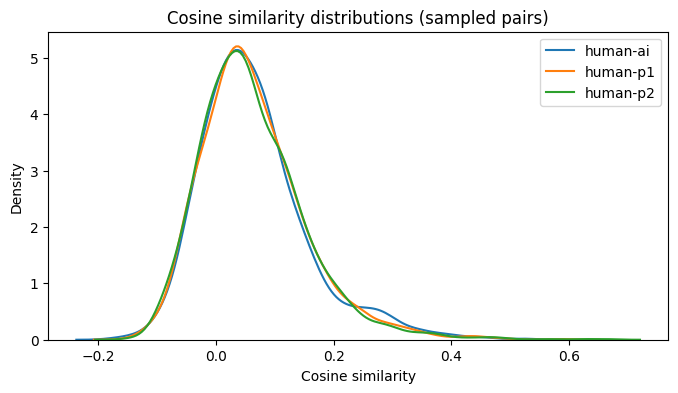

Embedding diagnostics saved.
Drift human→ai: 0.02297884225845337
Drift human→p1: 0.026183605194091797
Drift human→p2: 0.032048046588897705


In [41]:
# Cell: Embedding diagnostics (SBERT embeddings used)
# Compute centroids and cosine overlap distributions
from sklearn.metrics.pairwise import cosine_similarity

# Prepare embeddings for human, ai, ai-paraphrases
emb_human = sbert.encode(human_texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
emb_ai = sbert.encode(ai_texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
emb_ai_p1 = sbert.encode(ai_df['paraphrase_depth1'].tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True)
emb_ai_p2 = sbert.encode(ai_df['paraphrase_depth2'].tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True)

cent_h = emb_human.mean(axis=0)
cent_ai = emb_ai.mean(axis=0)
cent_p1 = emb_ai_p1.mean(axis=0)
cent_p2 = emb_ai_p2.mean(axis=0)

def cos(a,b): return float(np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12))
print("Centroid cosine similarities (human vs ai):", cos(cent_h, cent_ai))
print("Human vs paraphrase depth1:", cos(cent_h, cent_p1))
print("Human vs paraphrase depth2:", cos(cent_h, cent_p2))

# Overlap distributions: sample pairwise cosines
def sample_pairwise_cosines(A, B, n=2000):
    nA = len(A); nB = len(B)
    idxA = np.random.choice(nA, size=min(n, nA), replace=False)
    idxB = np.random.choice(nB, size=min(n, nB), replace=False)
    sims = []
    for i,j in zip(idxA, idxB):
        sims.append(cos(A[i], B[j]))
    return sims

sims_h_ai = sample_pairwise_cosines(emb_human, emb_ai)
sims_h_p1 = sample_pairwise_cosines(emb_human, emb_ai_p1)
sims_h_p2 = sample_pairwise_cosines(emb_human, emb_ai_p2)

# Plot distributions
plt.figure(figsize=(8,4))
sns.kdeplot(sims_h_ai, label='human-ai')
sns.kdeplot(sims_h_p1, label='human-p1')
sns.kdeplot(sims_h_p2, label='human-p2')
plt.legend()
plt.title("Cosine similarity distributions (sampled pairs)")
plt.xlabel("Cosine similarity")
plt.savefig(BASE / "embedding_overlap_kde.png", dpi=200)
plt.show()

# Save centroid vectors and stats
np.save(BASE / "centroid_human.npy", cent_h)
np.save(BASE / "centroid_ai.npy", cent_ai)
np.save(BASE / "centroid_p1.npy", cent_p1)
np.save(BASE / "centroid_p2.npy", cent_p2)
with open(BASE / "embedding_diagnostics.json", "w") as f:
    json.dump({
        "centroid_cos_h_ai": cos(cent_h,cent_ai),
        "centroid_cos_h_p1": cos(cent_h,cent_p1),
        "centroid_cos_h_p2": cos(cent_h,cent_p2),
        "tv_unigram": float(tv)
    }, f, indent=2)
print("Embedding diagnostics saved.")

# === GEOMETRIC DRIFT SUMMARY ===

def drift(a, b):
    return 1 - cos(a,b)

print("Drift human→ai:", drift(cent_h, cent_ai))
print("Drift human→p1:", drift(cent_h, cent_p1))
print("Drift human→p2:", drift(cent_h, cent_p2))



In [42]:
# === HUMAN AUDIT: WORST CASES ===

def worst_cases(df, y, p, k=5):
    err = np.abs(np.array(y) - np.array(p))
    idx = np.argsort(err)[-k:]
    return df.iloc[idx][['text','label']]

print("Worst SBERT p2 cases:")
display(worst_cases(par2, par2['label'], probs_par2))


Worst SBERT p2 cases:


,text,label
10554,so is everything else. 3. Savings will be non-...,1
2114,"As can be seen in [this image] , in most place...",0
7840,My name is Matthijs Kok and I'm a product desi...,1
6720,why it is present. Whenever a person types a k...,1
606,0 DALLAS BLUES DEVILS 4 1 1 0 3-0 W 1 at ANAHE...,0


In [48]:
final_summary = pd.DataFrame({
    "Paraphrase": {
        "SBERT": auc_par2_sbert,
        "BiLSTM": auc_par2_bilstm
    },
    "HRS": {
        "SBERT": hrs_sbert_df["delta"].mean(),
        "BiLSTM": hrs_bilstm_df["delta"].mean(),
        "Compression": hrs_comp_df["delta"].mean()
    },
    "RAIDAR_rewrite": {
        "SBERT": radar_df["Δ_sbert"].mean(),
        "BiLSTM": radar_df["Δ_bilstm"].mean()
    },
    "Back_translation": {
        "SBERT": bt_df["Δ_sbert"].mean(),
        "BiLSTM": bt_df["Δ_bilstm"].mean()
    }
})

display(final_summary)


,Paraphrase,HRS,RAIDAR_rewrite,Back_translation
SBERT,0.802861,-0.191166,0.042740,0.140146
BiLSTM,0.931750,-0.138256,-0.068927,-0.074062
Compression,NaN,-0.022179,NaN,NaN
